Importing the Libraries

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import f_oneway, pearsonr
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.outliers_influence import variance_inflation_factor


Importing the Database by reading the CSV file

In [24]:
my_data = pd.read_csv("Economy_of_US.csv")
key_metrics = my_data[["GDP_PPP", "GDP_Nominal", "GDP_PerCapita_PPP","GDP_PerCapita_Nominal"]]

To ensure the data is ready to use, I will check and remove duplicates and ensure all data contained in each field is associated with an appropriate datatype, based on the schema

In [25]:
my_data.drop_duplicates(inplace=True)
my_data.dropna()


,Year,GDP_PPP,GDP_PerCapita_PPP,GDP_Nominal,GDP_PerCapita_Nominal,GDP_Growth,Inflation,Unemployment,Inflation_Change
1,1981,3207.0,13948.7,3207.0,13948.7,0.025,0.104,0.076,Decrease
2,1982,3343.8,14405.0,3343.8,14405.0,-0.018,0.062,0.097,Decrease
3,1983,3634.0,15513.7,3634.0,15513.7,0.046,0.032,0.096,Decrease
4,1984,4037.7,17086.4,4037.7,17086.4,0.072,0.044,0.075,Increase
5,1985,4339.0,18199.3,4339.0,18199.3,0.042,0.035,0.072,Decrease
6,1986,4579.6,19034.8,4579.6,19034.8,0.035,0.019,0.070,Decrease
7,1987,4855.3,20001.0,4855.3,20001.0,0.035,0.036,0.062,Increase
8,1988,5236.4,21376.0,5236.4,21376.0,0.042,0.041,0.055,Increase
9,1989,5641.6,22814.1,5641.6,22814.1,0.037,0.048,0.053,Increase
10,1990,5963.1,23848.0,5963.1,23848.0,0.019,0.054,0.056,Increase


There were also anomaly values found in the SQL Analysis, which were from the years 2026 and 2027

Computing Statistical Values

In [26]:
key_metrics = my_data[["GDP_PPP", "GDP_Nominal", "GDP_PerCapita_PPP","GDP_PerCapita_Nominal"]]
means = key_metrics.describe()

Visualizing the Data

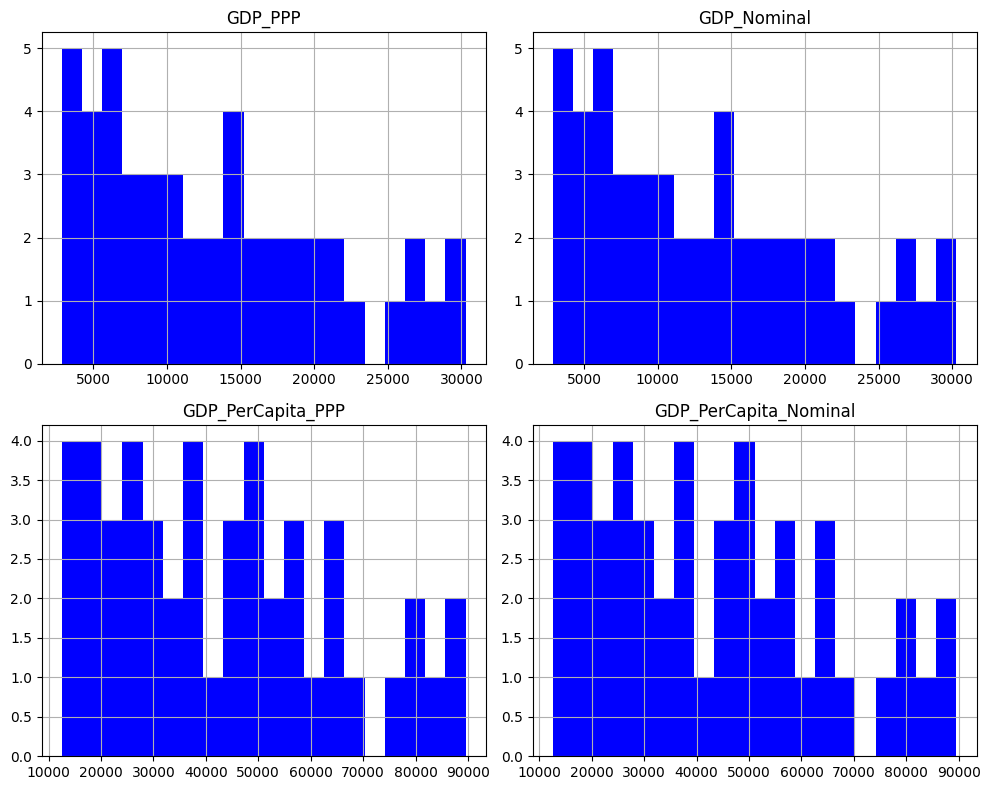

In [27]:
key_metrics.hist(layout=(2, 2), figsize=(10, 8), bins=20, color='blue')
plt.tight_layout()
plt.show()


Inspecting for Outliers using a Box Plot

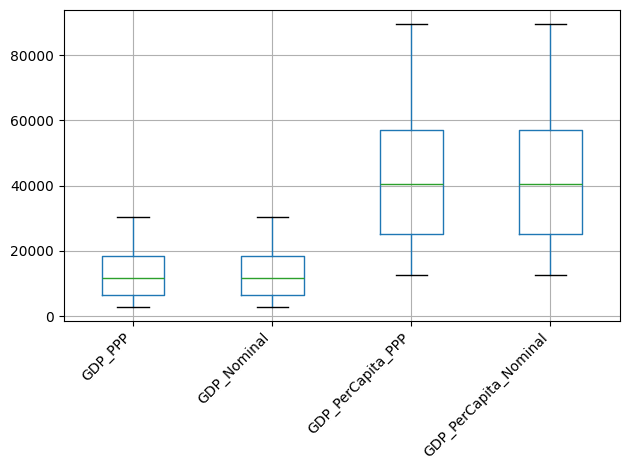

In [28]:
key_metrics.boxplot()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Test Statistics

Using ANOVA (Analysis of Variance), I tested if GDP growth differs significantly across decades. ANOVA (Analysis of Variance), is used to compare groups of data and determine if the mean differs across them significantly. Here, the data need to be separated into groups of 10 records. 

In [29]:


df = key_metrics
df = df.copy()

df.loc[:, "Decade"] = (my_data["Year"] // 10) * 10

# Group GDP growth values by decade
decade_groups = [
    group["GDP_PPP"].dropna()
    for name, group in df.groupby("Decade")
]

# Perform ANOVA
anova_result = f_oneway(*decade_groups)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)


F-statistic: 184.96605302430424
p-value: 1.714280129069908e-26


From this result, at a error of 5%, it is necessary to reject the null hypothesis and conclude that there is no significant difference among the variables. Because the F-Statistic Value is relatively high, the GDP metric means have a relatively large variation between them

In [30]:
gdp_columns = [
    "GDP_PPP",
    "GDP_PerCapita_PPP",
    "GDP_Nominal",
    "GDP_PerCapita_Nominal",
    "GDP_Growth"
]

print("\nPearson Correlation Significance Tests")

for i in range(len(gdp_columns)):
    for j in range(i+1, len(gdp_columns)):
        col1 = gdp_columns[i]
        col2 = gdp_columns[j]

        r, p = pearsonr(df[col1], df[col2])

        print(f"{col1} vs {col2}")
        print("  r =", r)
        print("  p =", p)



Pearson Correlation Significance Tests
GDP_PPP vs GDP_PerCapita_PPP
  r = 0.9991231813965074
  p = 4.7293370182748845e-65
GDP_PPP vs GDP_Nominal
  r = 0.9999999999999999
  p = 0.0
GDP_PPP vs GDP_PerCapita_Nominal
  r = 0.9991231813965074
  p = 4.7293370182748845e-65


KeyError: 'GDP_Growth'

In [31]:


time_series_columns = [
    "GDP_PPP",
    "GDP_PerCapita_PPP",
    "GDP_Nominal",
    "GDP_PerCapita_Nominal",
    "GDP_Growth"
]

for col in time_series_columns:
    result = adfuller(df[col].dropna())

    print(f"\nADF Test for {col}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    if result[1] < 0.05:
        print("Result: Stationary")
    else:
        print("Result: Non-stationary")


ADF Test for GDP_PPP
ADF Statistic: 4.046360526135578
p-value: 1.0
Result: Non-stationary

ADF Test for GDP_PerCapita_PPP
ADF Statistic: 3.4568938712163373
p-value: 1.0
Result: Non-stationary

ADF Test for GDP_Nominal
ADF Statistic: 4.046360526135578
p-value: 1.0
Result: Non-stationary

ADF Test for GDP_PerCapita_Nominal
ADF Statistic: 3.4568938712163373
p-value: 1.0
Result: Non-stationary


KeyError: 'GDP_Growth'

In [ ]:
gdp_vars = [
    "GDP_PPP",
    "GDP_PerCapita_PPP",
    "GDP_Nominal",
    "GDP_PerCapita_Nominal",
    "GDP_Growth"
]

corr_matrix = df[gdp_vars].corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix of GDP Variables")
plt.show()

NameError: name 'gdp_vars' is not defined

In [ ]:
# Select predictor variables
X = df[gdp_vars].dropna()

# Create VIF dataframe
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif_data)

The correlation matrix reveals strong positive relationships among GDP metrics. Nominal GDP, PPP GDP, and their per-capita counterparts exhibit correlations above 0.9, indicating they move closely together over time. GDP growth shows weaker correlations with level variables, reflecting its role as a rate of change rather than an absolute economic size measure.

Variance Inflation Factor (VIF) analysis confirms substantial multicollinearity among GDP level variables. Nominal GDP, PPP GDP, and their per-capita versions display elevated VIF values, suggesting redundancy among predictors. This is expected since these metrics measure similar economic activity using different adjustments.

Due to high multicollinearity, including all GDP level variables in a regression model may lead to unstable coefficient estimates. To address this issue, dimensionality reduction techniques such as Principal Component Analysis (PCA) or selecting a representative GDP metric (e.g., GDP per capita PPP) may improve model interpretability and robustness.